<a href="https://colab.research.google.com/github/iMasewi/-OOP-PTIT---QLDA/blob/master/Copy_of_TrainingModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Import libraries necessery
import matplotlib.pyplot as plt
import cv2
import numpy as np
import tensorflow
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.utils import to_categorical
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 2. Read & preprocessing datas
data = pd.read_csv(r"A_Z Handwritten Data.csv").astype('float32')

print(data.head(10))

     0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  ...  0.639  0.640  0.641  \
0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0    0.0    0.0   
1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0    0.0    0.0   
2  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0    0.0    0.0   
3  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0    0.0    0.0   
4  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0    0.0    0.0   
5  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0    0.0    0.0   
6  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0    0.0    0.0   
7  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0    0.0    0.0   
8  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0    0.0    0.0   
9  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0    0.0    0.0   

   0.642  0.643  0.644  0.645  0.646  0.647  0.648  
0    0.0    0.0    0.0    0.0    0.0    0.0    0.0  
1 

In [ ]:
## Split data into images and their labels
X = data.drop('0', axis=1)
y = data['0']

In [ ]:
train_x, test_x, train_y, test_y = train_test_split(X, y, test_size=0.2)

## Reshape the train to images
train_x = np.reshape(train_x.values, (train_x.shape[0], 28, 28))
test_x = np.reshape(test_x.values, (test_x.shape[0], 28, 28))

In [ ]:
train_x.shape

(297960, 28, 28)

In [ ]:
test_x.shape

(74490, 28, 28)

In [ ]:
word_dict = {0:'A',1:'B',2:'C',3:'D',4:'E',5:'F',6:'G',7:'H',8:'I',9:'J',10:'K',11:'L',12:'M',13:'N',14:'O',15:'P',16:'Q',17:'R',18:'S',19:'T',20:'U',21:'V',22:'W',23:'X', 24:'Y',25:'Z'}

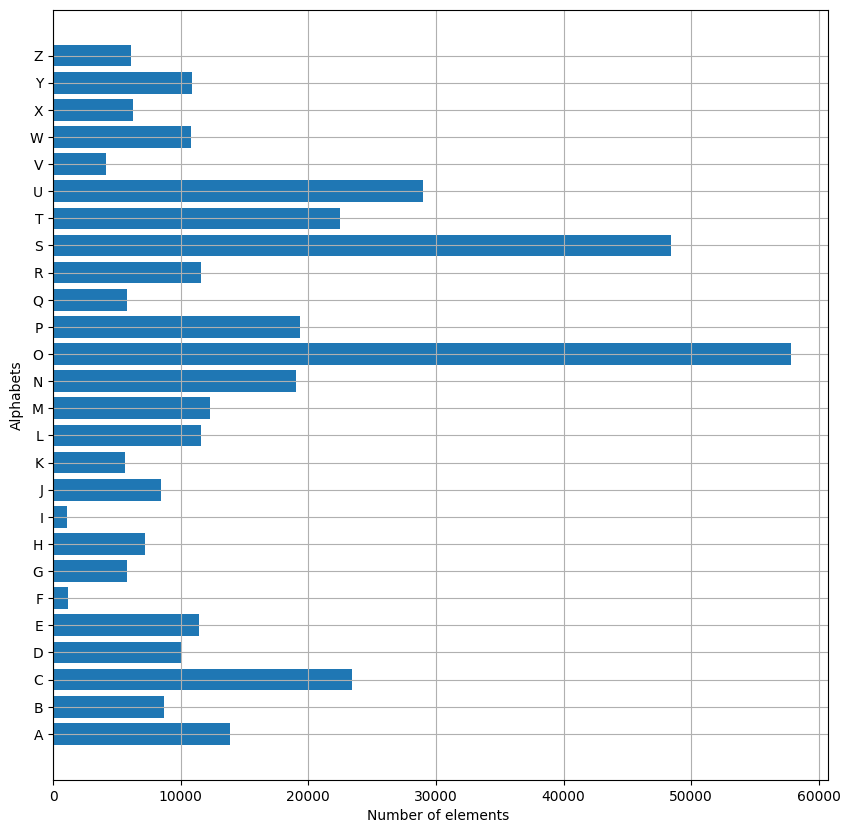

In [ ]:
# 3. Plotting the number of alphabets in the dataset ==> More understanding distribution dataset
y_int = y.astype(int)
count = np.zeros(26, dtype='int')
for i in y_int:
    count[i] += 1

    alphabets = []
    for i in word_dict.values():
        alphabets.append(i)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.barh(alphabets, count)

plt.xlabel("Number of elements ")
plt.ylabel("Alphabets")
plt.grid()
plt.show()

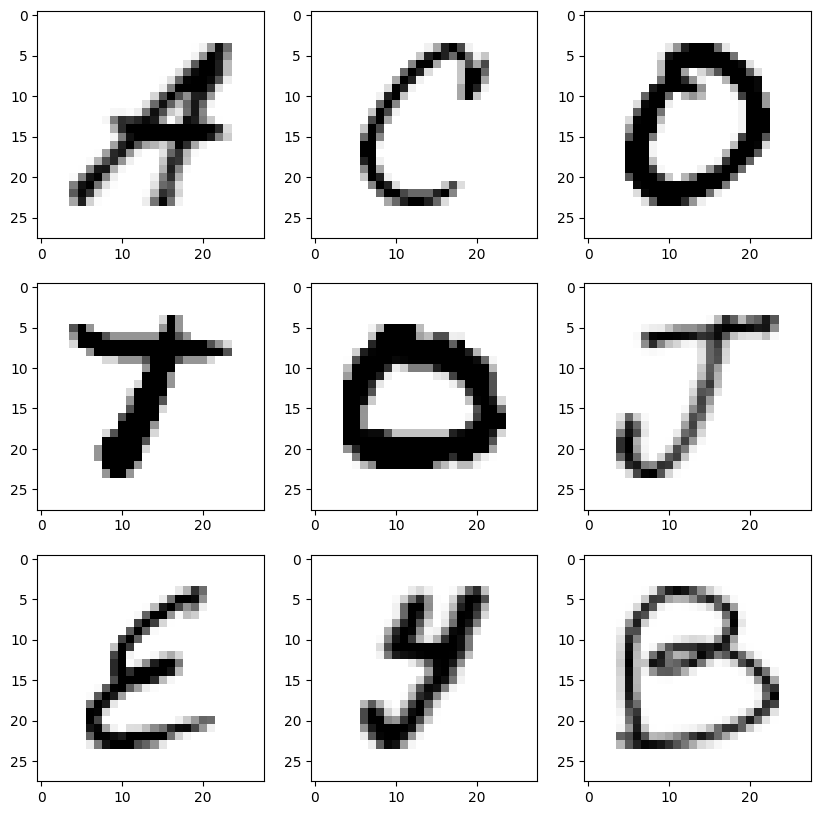

In [ ]:
# 4. Shuffling the data
shuff = shuffle(train_x[:100])

fig, ax = plt.subplots(3, 3, figsize=(10, 10))
axes = ax.flatten()

for i in range(9):
    _, shu = cv2.threshold(shuff[i], 30, 200, cv2.THRESH_BINARY)
    axes[i].imshow(np.reshape(shuff[i], (28, 28)), cmap="Greys")
plt.show()


In [ ]:
# Reshaping the train & set dataset to put in model
train_X = train_x.reshape(train_x.shape[0],train_x.shape[1],train_x.shape[2],1)
print("New shape of train data: ", train_X.shape)

test_X = test_x.reshape(test_x.shape[0], test_x.shape[1], test_x.shape[2],1)
print("New shape of train data: ", test_X.shape)

train_X = train_X / 255.0
test_X = test_X / 255.0
print("Data normalized!")


New shape of train data:  (297960, 28, 28, 1)
New shape of train data:  (74490, 28, 28, 1)
Data normalized!


In [ ]:
train_yOHE = to_categorical(train_y, num_classes = 26)
print("New shape of train labels: ", train_yOHE.shape)

test_yOHE = to_categorical(test_y, num_classes = 26)
print("New shape of test labels: ", test_yOHE.shape)

New shape of train labels:  (297960, 26)
New shape of test labels:  (74490, 26)


In [ ]:
# Create Improved Model
model = Sequential()

# Block 1
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28,28,1)))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Block 2
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Block 3
model.add(Conv2D(128, (3, 3), activation='relu', padding='valid'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.4))

# Dense layers
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(26, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer=Adam(learning_rate=0.001),
             loss='categorical_crossentropy',
             metrics=['accuracy'])


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 262,170 (1.00 MB)

 Trainable params: 261,210 (1020.35 KB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
import datetime
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tensorflow.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=0.00001,
    verbose=1
)

# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)
datagen.fit(train_X)
steps_per_epoch = len(train_X) // 128

# Fit training
history = model.fit(
    datagen.flow(train_X, train_yOHE, batch_size=128),
    steps_per_epoch=steps_per_epoch,
    epochs=30,
    validation_data=(test_X, test_yOHE),
    callbacks=[tensorboard_callback, early_stopping, model_checkpoint, reduce_lr],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
2327/2327 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6695 - loss: 1.2363
Epoch 1: val_accuracy improved from -inf to 0.97929, saving model to /content/drive/MyDrive/best_model.h5


2327/2327 ━━━━━━━━━━━━━━━━━━━━ 137s 53ms/step - accuracy: 0.6696 - loss: 1.2361 - val_accuracy: 0.9793 - val_loss: 0.0749 - learning_rate: 0.0010
Epoch 2/30
   1/2327 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - accuracy: 0.9375 - loss: 0.2462

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.97929
2327/2327 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9375 - loss: 0.2462 - val_accuracy: 0.9793 - val_loss: 0.0750 - learning_rate: 0.0010
Epoch 3/30
2326/2327 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9313 - loss: 0.2416
Epoch 3: val_accuracy improved from 0.97929 to 0.98300, saving model to /content/drive/MyDrive/best_model.h5


...

2327/2327 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9531 - loss: 0.1768 - val_accuracy: 0.9892 - val_loss: 0.0421 - learning_rate: 5.0000e-04
Epoch 19/30
2327/2327 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9721 - loss: 0.1042
Epoch 19: val_accuracy improved from 0.98919 to 0.98960, saving model to /content/drive/MyDrive/best_model.h5


2327/2327 ━━━━━━━━━━━━━━━━━━━━ 113s 49ms/step - accuracy: 0.9721 - loss: 0.1042 - val_accuracy: 0.9896 - val_loss: 0.0412 - learning_rate: 5.0000e-04
Epoch 20/30
   1/2327 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - accuracy: 0.9922 - loss: 0.0367
Epoch 20: val_accuracy did not improve from 0.98960
2327/2327 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9922 - loss: 0.0367 - val_accuracy: 0.9896 - val_loss: 0.0412 - learning_rate: 5.0000e-04
Epoch 21/30
2327/2327 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9729 - loss: 0.1025
Epoch 21: val_accuracy did not improve from 0.98960
2327/2327 ━━━━━━━━━━━━━━━━━━━━ 111s 48ms/step - accuracy: 0.9729 - loss: 0.1025 - val_accuracy: 0.9895 - val_loss: 0.0419 - learning_rate: 5.0000e-04
Epoch 22/30
   1/2327 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - accuracy: 0.9922 - loss: 0.0539
Epoch 22: val_accuracy did not improve from 0.98960

Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
2327/2327 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - ac

2327/2327 ━━━━━━━━━━━━━━━━━━━━ 112s 48ms/step - accuracy: 0.9746 - loss: 0.0976 - val_accuracy: 0.9901 - val_loss: 0.0396 - learning_rate: 2.5000e-04
Epoch 24/30
   1/2327 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - accuracy: 0.9766 - loss: 0.0777
Epoch 24: val_accuracy did not improve from 0.99007
2327/2327 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9766 - loss: 0.0777 - val_accuracy: 0.9901 - val_loss: 0.0396 - learning_rate: 2.5000e-04
Epoch 25/30
2327/2327 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9753 - loss: 0.0939
Epoch 25: val_accuracy did not improve from 0.99007
2327/2327 ━━━━━━━━━━━━━━━━━━━━ 112s 48ms/step - accuracy: 0.9753 - loss: 0.0939 - val_accuracy: 0.9898 - val_loss: 0.0403 - learning_rate: 2.5000e-04
Epoch 26/30
   1/2327 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - accuracy: 0.9766 - loss: 0.0738
Epoch 26: val_accuracy did not improve from 0.99007

Epoch 26: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
2327/2327 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - ac

2327/2327 ━━━━━━━━━━━━━━━━━━━━ 113s 49ms/step - accuracy: 0.9756 - loss: 0.0917 - val_accuracy: 0.9907 - val_loss: 0.0388 - learning_rate: 1.2500e-04
Epoch 28/30
   1/2327 ━━━━━━━━━━━━━━━━━━━━ 35s 15ms/step - accuracy: 0.9844 - loss: 0.0245
Epoch 28: val_accuracy did not improve from 0.99070
2327/2327 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9844 - loss: 0.0245 - val_accuracy: 0.9906 - val_loss: 0.0388 - learning_rate: 1.2500e-04
Epoch 29/30
2327/2327 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9760 - loss: 0.0918
Epoch 29: val_accuracy improved from 0.99070 to 0.99079, saving model to /content/drive/MyDrive/best_model.h5


2327/2327 ━━━━━━━━━━━━━━━━━━━━ 114s 49ms/step - accuracy: 0.9760 - loss: 0.0918 - val_accuracy: 0.9908 - val_loss: 0.0384 - learning_rate: 1.2500e-04
Epoch 30/30
   1/2327 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accuracy: 0.9609 - loss: 0.1339
Epoch 30: val_accuracy did not improve from 0.99079
2327/2327 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9609 - loss: 0.1339 - val_accuracy: 0.9908 - val_loss: 0.0384 - learning_rate: 1.2500e-04
Restoring model weights from the end of the best epoch: 29.



📊 ĐÁNH GIÁ CHI TIẾT MODEL

2328/2328 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
📋 Classification Report (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           A       0.99      1.00      0.99      2796
           B       0.99      0.99      0.99      1726
           C       0.99      0.99      0.99      4641
           D       0.97      0.95      0.96      1938
           E       1.00      0.99      0.99      2260
           F       0.98      1.00      0.99       228
           G       0.99      0.97      0.98      1178
           H       0.98      0.98      0.98      1494
           I       0.96      0.99      0.97       194
           J       0.98      0.97      0.98      1775
           K       0.98      0.98      0.98      1130
           L       0.99      0.98      0.99      2325
           M       0.99      1.00      0.99      2440
           N       0.99      0.99      0.99      3877
           O       0.99      0.99      0.99     11654
         

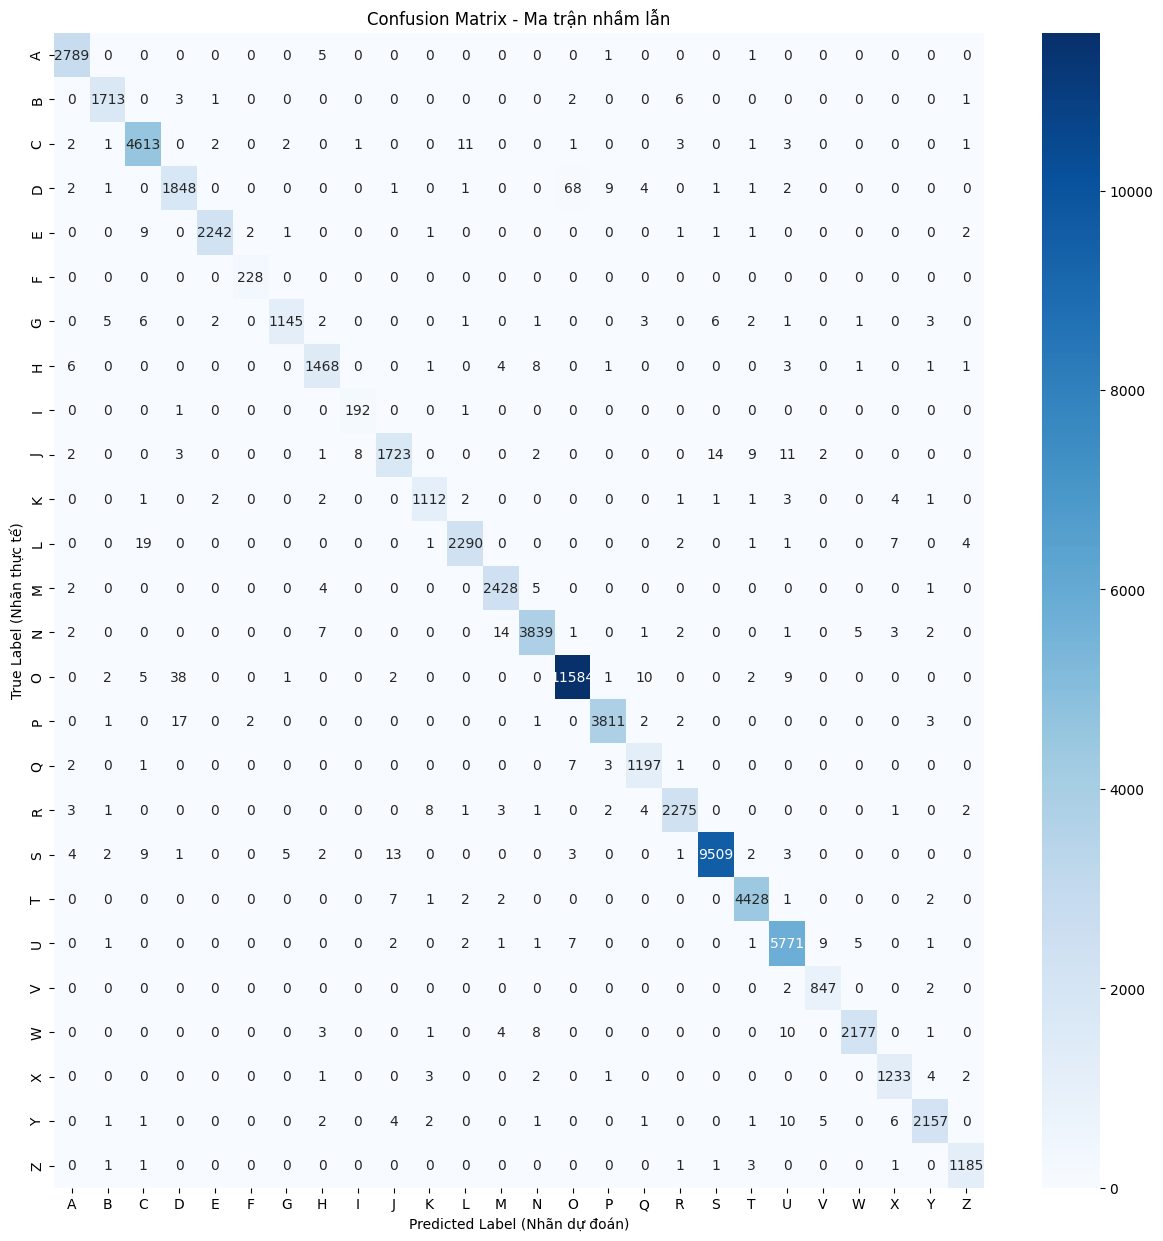


📈 Đang vẽ Learning Curves...


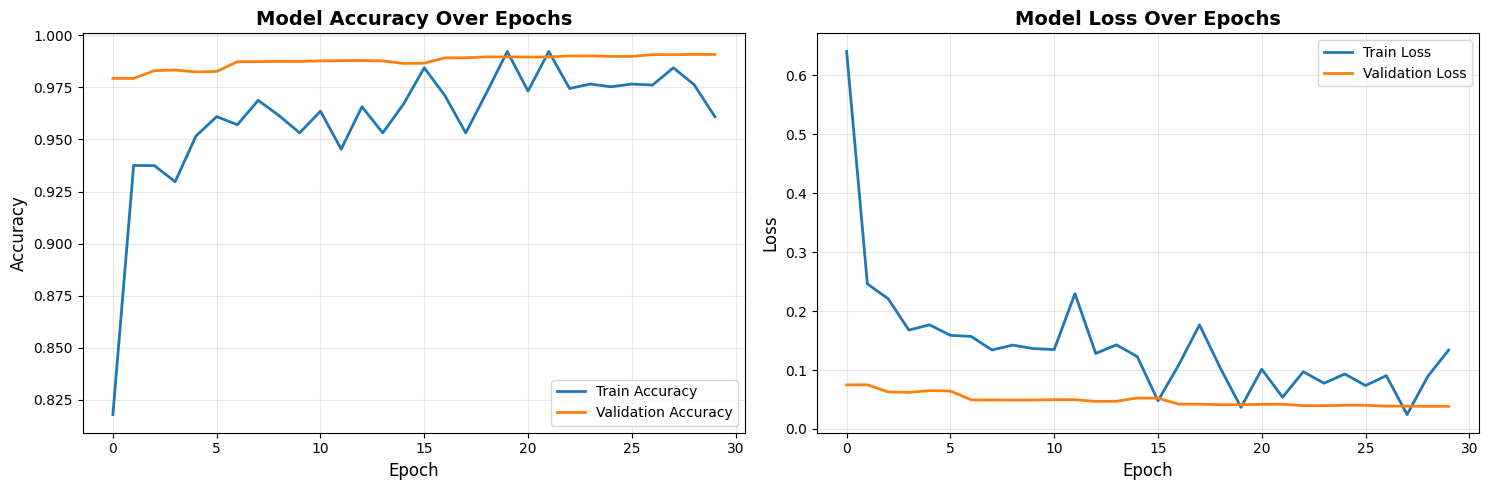


📊 TỔNG KẾT KẾT QUẢ:
--------------------------------------------------
✅ Final Training Accuracy: 0.9609
✅ Final Validation Accuracy: 0.9908
✅ Final Training Loss: 0.1339
✅ Final Validation Loss: 0.0384
✅ Best Validation Accuracy: 0.9908
--------------------------------------------------


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("\n" + "="*50)
print("📊 ĐÁNH GIÁ CHI TIẾT MODEL")
print("="*50 + "\n")

# Predict trên test set
y_pred = model.predict(test_X)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(test_yOHE, axis=1)

# 1. Classification Report
print("📋 Classification Report (Precision, Recall, F1-Score):")
print(classification_report(y_true, y_pred_classes, target_names=list(word_dict.values())))

# 2. Confusion Matrix
print("\n📊 Đang vẽ Confusion Matrix...")
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(15, 15))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(word_dict.values()),
            yticklabels=list(word_dict.values()))
plt.title('Confusion Matrix - Ma trận nhầm lẫn')
plt.ylabel('True Label (Nhãn thực tế)')
plt.xlabel('Predicted Label (Nhãn dự đoán)')
plt.show()

# 3. Training History Plots
print("\n📈 Đang vẽ Learning Curves...")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot Loss
axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Summary Statistics
print("\n📊 TỔNG KẾT KẾT QUẢ:")
print("-" * 50)
print(f"✅ Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"✅ Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"✅ Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"✅ Final Validation Loss: {history.history['val_loss'][-1]:.4f}")
print(f"✅ Best Validation Accuracy: {max(history.history['val_accuracy']):.4f}")
print("-" * 50)

In [ ]:

# Lưu model vào file .h5
model.save('/content/drive/MyDrive/modelHandWritten.h5')


In [ ]:
print("The validation accuracy is :", history.history['val_accuracy'])
print("The training accuracy is :", history.history['accuracy'])
print("The validation loss is :", history.history['val_loss'])
print("The training loss is :", history.history['loss'])

NameError: name 'history' is not defined

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 749ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


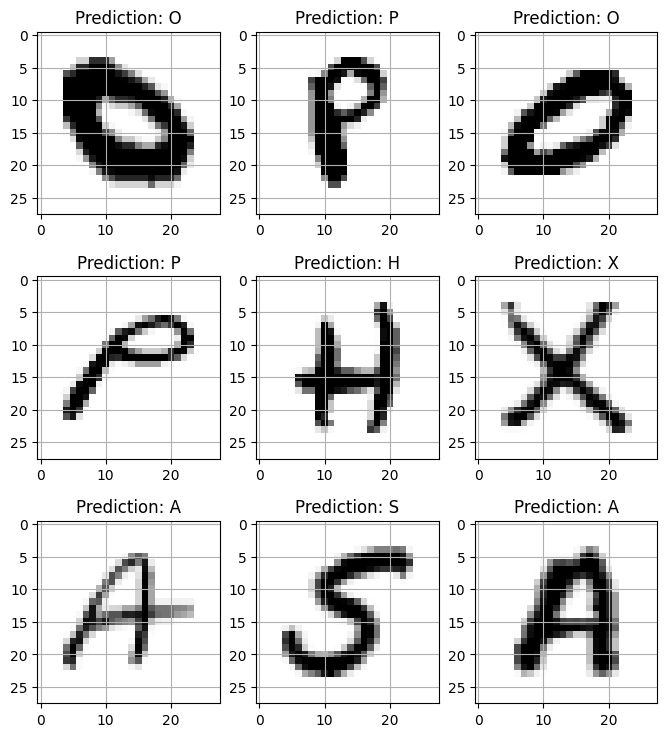

In [ ]:
# Predict some test data
fig, axes = plt.subplots(3, 3, figsize=(8,9))
axes = axes.flatten()

for i, ax in enumerate(axes):
    img = np.reshape(test_X[i], (28, 28))
    ax.imshow(img, cmap="Greys")

    pred = word_dict[np.argmax(model.predict(test_X[i].reshape(1,28,28,1)))]
    ax.set_title("Prediction: " + pred)
    ax.grid()

In [ ]:
model = tensorflow.keras.models.load_model('/content/drive/MyDrive/modelHandWritten.h5')


In [ ]:
# prediction on external image
img = cv2.imread(r'Test7.png')
img_copy = img.copy()

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (400, 400))

img_copy = cv2.GaussianBlur(img_copy, (7,7), 0)
img_gray = cv2.cvtColor(img_copy, cv2.COLOR_BGR2GRAY)
_, img_thresh = cv2.threshold(img_gray, 100, 255, cv2.THRESH_BINARY_INV)

img_final = cv2.resize(img_thresh, (28, 28))
img_final = np.reshape(img_final, (1, 28, 28, 1))
img_final = img_final / 255.0

img_pred = word_dict[np.argmax(model.predict(img_final))]

# cv2.putText(img, "Prediction: " + img_pred, (20, 410), cv2.FONT_HERSHEY_DUPLEX, 1.3, (255, 0, 30))
# cv2.imshow("result", img)

img_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


'Z'

True